# 1. Context and data preparation

## 1.1. Experimental Setup

&emsp;The following cell initializes the directory structure and environmental constraints. It establishes the paths for the **StressID** dataset and defines the exclusion criteria for damaged samples and non-verbal tasks.

In [31]:
# =========================
# 1. EXPERIMENTAL SETUP
# =========================

import os
import sys
import random
import subprocess
from datetime import datetime

import numpy as np
import pandas as pd
import librosa
import tqdm
import xgboost as xgb
import matplotlib.pyplot as plt

# --- 1.1 REPRODUCIBILITY ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# --- 1.2 EXECUTION ENVIRONMENT DETECTION ---
IN_COLAB = "google.colab" in sys.modules
EXECUTION_MODE = "colab" if IN_COLAB else "local"

# ------------------------------------------------------------
# REPOSITORY CONFIGURATION
# ------------------------------------------------------------
GITHUB_REPO_URL = "https://github.com/gabasosa/thesis-stress-recognition.git"
REPO_NAME = "thesis-stress-recognition"

# ------------------------------------------------------------
# COLAB / LOCAL BOOTSTRAP
# ------------------------------------------------------------
if IN_COLAB:
    print("Google Colab environment detected.")

    THESIS_REPO_DIR = os.path.join("/content", REPO_NAME)

    if not os.path.exists(THESIS_REPO_DIR):
        print(f"Cloning repository into {THESIS_REPO_DIR} ...")
        subprocess.run(
            ["git", "clone", GITHUB_REPO_URL, THESIS_REPO_DIR],
            check=True
        )
    else:
        print(f"Repository already present at {THESIS_REPO_DIR}")

    # Default Colab workspace root
    BASE_DIR = "/content/Tesis"

    # Optional Drive integration only if needed later
    DRIVE_DIR = "/content/drive"
    DRIVE_MOUNTED = os.path.exists(os.path.join(DRIVE_DIR, "MyDrive"))

    def maybe_mount_drive():
        global DRIVE_MOUNTED
        if not DRIVE_MOUNTED:
            from google.colab import drive
            print("Mounting Google Drive ...")
            drive.mount(DRIVE_DIR)
            DRIVE_MOUNTED = True

else:
    print("Local environment detected.")

    BASE_DIR = os.path.expanduser("~/Documents/Facultad/Tesis")
    THESIS_REPO_DIR = os.path.join(BASE_DIR, "GitHub", REPO_NAME)
    DRIVE_DIR = os.path.join(BASE_DIR, "Drive")
    DRIVE_MOUNTED = os.path.exists(DRIVE_DIR)

    def maybe_mount_drive():
        # No-op on local execution
        return

# ============================================================
# BASE PATHS
# ============================================================

ADMIN_DIR = os.path.join(BASE_DIR, "administrative")
BACKUP_DIR = os.path.join(BASE_DIR, "backup")
DATASETS_DIR = os.path.join(BASE_DIR, "datasets")
MODELS_DIR = os.path.join(BASE_DIR, "models")
GITHUB_DIR = os.path.join(BASE_DIR, "GitHub")

# ============================================================
# DATASETS
# ============================================================

RAW_DATA_DIR = os.path.join(DATASETS_DIR, "raw")
UNPACKED_DATA_DIR = os.path.join(DATASETS_DIR, "unpacked")
PROCESSED_DATA_DIR = os.path.join(DATASETS_DIR, "processed")

STRESSID_ROOT = os.path.join(UNPACKED_DATA_DIR, "StressID")
VERBIO_ROOT = os.path.join(UNPACKED_DATA_DIR, "VerBIO_v2")

# ============================================================
# MODELS
# ============================================================

WAV2VEC_MODELS_DIR = os.path.join(MODELS_DIR, "wav2vec")

WAV2VEC_LARGE_PT = os.path.join(WAV2VEC_MODELS_DIR, "wav2vec_large.pt")
WAV2VEC_VOX_NEW_PT = os.path.join(WAV2VEC_MODELS_DIR, "wav2vec_vox_new.pt")

# ============================================================
# GITHUB PROJECT
# ============================================================

CONFIGS_DIR = os.path.join(THESIS_REPO_DIR, "configs")
EXPERIMENTS_DIR = os.path.join(THESIS_REPO_DIR, "experiments")
OPTUNA_DIR = os.path.join(EXPERIMENTS_DIR, "optuna")
EXTERNAL_DIR = os.path.join(THESIS_REPO_DIR, "external")
NOTEBOOKS_DIR = os.path.join(THESIS_REPO_DIR, "notebooks")
SCRIPTS_DIR = os.path.join(THESIS_REPO_DIR, "scripts")
SRC_DIR = os.path.join(THESIS_REPO_DIR, "src")

STRESSID_FORK_GITHUB_DIR = os.path.join(EXTERNAL_DIR, "stressID-fork")
VAD_DIR = os.path.join(STRESSID_FORK_GITHUB_DIR, "Feature Extraction", "audio")

# ============================================================
# OUTPUT DIRECTORIES
# ============================================================

CACHE_DIR = os.path.join(EXPERIMENTS_DIR, "cache")
EVAL_DIR = os.path.join(EXPERIMENTS_DIR, "evaluation")
IMPORTANCE_DIR = os.path.join(EXPERIMENTS_DIR, "importance")

for d in [EXPERIMENTS_DIR, OPTUNA_DIR, CACHE_DIR, EVAL_DIR, IMPORTANCE_DIR]:
    os.makedirs(d, exist_ok=True)

# ============================================================
# OPTIONAL DRIVE FALLBACKS (COLAB ONLY)
# ============================================================
# These are only used if the default /content/Tesis paths are missing.
# Adjust them only if you later decide to keep datasets/models in Drive.

if IN_COLAB:
    DRIVE_BASE_DIR = os.path.join(DRIVE_DIR, "MyDrive", "Tesis")
    DRIVE_DATASETS_DIR = os.path.join(DRIVE_BASE_DIR, "datasets")
    DRIVE_MODELS_DIR = os.path.join(DRIVE_BASE_DIR, "models")

    # If datasets are not present in /content/Tesis, optionally try Drive
    if not os.path.exists(STRESSID_ROOT) or not os.path.exists(VERBIO_ROOT):
        print("Local Colab datasets not found under /content/Tesis.")
        print("If needed, the notebook can mount Drive and use datasets from there.")

    # If models are not present in /content/Tesis, optionally try Drive
    if not os.path.exists(WAV2VEC_LARGE_PT) and not os.path.exists(WAV2VEC_VOX_NEW_PT):
        print("Local Colab wav2vec checkpoints not found under /content/Tesis.")
        print("If needed, the notebook can mount Drive and use models from there.")

# ============================================================
# OPTIONAL: add local code to sys.path
# ============================================================

for p in [SRC_DIR, SCRIPTS_DIR, VAD_DIR]:
    if os.path.exists(p) and p not in sys.path:
        sys.path.insert(0, p)

# ============================================================
# RESOURCE FLAGS
# ============================================================

HAS_THESIS_REPO = os.path.exists(THESIS_REPO_DIR)
HAS_EXPERIMENTS_DIR = os.path.exists(EXPERIMENTS_DIR)
HAS_STRESSID_DATASET = os.path.exists(STRESSID_ROOT)
HAS_VERBIO_DATASET = os.path.exists(VERBIO_ROOT)
HAS_WAV2VEC_LARGE = os.path.exists(WAV2VEC_LARGE_PT)
HAS_WAV2VEC_VOX_NEW = os.path.exists(WAV2VEC_VOX_NEW_PT)
HAS_VAD_DIR = os.path.exists(VAD_DIR)

# ------------------------------------------------------------
# OPTIONAL DRIVE RESOLUTION FOR COLAB
# ------------------------------------------------------------
# If datasets or models are missing in Colab, ask whether to mount Drive
# and try resolving them from /content/drive/MyDrive/Tesis.

if IN_COLAB and (not HAS_STRESSID_DATASET or not HAS_WAV2VEC_LARGE):
    user_input = input(
        "Datasets and/or local wav2vec checkpoints are missing in Colab. "
        "Do you want to try Google Drive as a fallback? (y/n): "
    ).strip().lower()

    if user_input == "y":
        maybe_mount_drive()

        # Dataset fallback
        drive_stressid_root = os.path.join(DRIVE_DATASETS_DIR, "unpacked", "StressID")
        drive_verbio_root = os.path.join(DRIVE_DATASETS_DIR, "unpacked", "VerBIO_v2")

        if not HAS_STRESSID_DATASET and os.path.exists(drive_stressid_root):
            STRESSID_ROOT = drive_stressid_root
            HAS_STRESSID_DATASET = True

        if not HAS_VERBIO_DATASET and os.path.exists(drive_verbio_root):
            VERBIO_ROOT = drive_verbio_root
            HAS_VERBIO_DATASET = True

        # Model fallback
        drive_wav2vec_models_dir = os.path.join(DRIVE_MODELS_DIR, "wav2vec")
        drive_wav2vec_large_pt = os.path.join(drive_wav2vec_models_dir, "wav2vec_large.pt")
        drive_wav2vec_vox_new_pt = os.path.join(drive_wav2vec_models_dir, "wav2vec_vox_new.pt")

        if not HAS_WAV2VEC_LARGE and os.path.exists(drive_wav2vec_large_pt):
            WAV2VEC_MODELS_DIR = drive_wav2vec_models_dir
            WAV2VEC_LARGE_PT = drive_wav2vec_large_pt
            HAS_WAV2VEC_LARGE = True

        if not HAS_WAV2VEC_VOX_NEW and os.path.exists(drive_wav2vec_vox_new_pt):
            WAV2VEC_VOX_NEW_PT = drive_wav2vec_vox_new_pt
            HAS_WAV2VEC_VOX_NEW = True

# ============================================================
# SANITY REPORT
# ============================================================

print("====================================================")
print(" EXPERIMENTAL ENVIRONMENT")
print("====================================================")
print("EXECUTION_MODE:", EXECUTION_MODE)
print("IN_COLAB:", IN_COLAB)
print("BASE_DIR:", BASE_DIR)
print("THESIS_REPO_DIR:", THESIS_REPO_DIR)
print("DATASETS_DIR:", DATASETS_DIR)
print("STRESSID_ROOT:", STRESSID_ROOT)
print("VERBIO_ROOT:", VERBIO_ROOT)
print("WAV2VEC_MODELS_DIR:", WAV2VEC_MODELS_DIR)
print("VAD_DIR:", VAD_DIR)
print("CACHE_DIR:", CACHE_DIR)
print("OPTUNA_DIR:", OPTUNA_DIR)
print("DRIVE_MOUNTED:", DRIVE_MOUNTED)
print("====================================================")
print("HAS_THESIS_REPO:", HAS_THESIS_REPO)
print("HAS_EXPERIMENTS_DIR:", HAS_EXPERIMENTS_DIR)
print("HAS_STRESSID_DATASET:", HAS_STRESSID_DATASET)
print("HAS_VERBIO_DATASET:", HAS_VERBIO_DATASET)
print("HAS_WAV2VEC_LARGE:", HAS_WAV2VEC_LARGE)
print("HAS_WAV2VEC_VOX_NEW:", HAS_WAV2VEC_VOX_NEW)
print("HAS_VAD_DIR:", HAS_VAD_DIR)
print("====================================================")

assert HAS_THESIS_REPO, f"Missing THESIS_REPO_DIR: {THESIS_REPO_DIR}"
assert HAS_EXPERIMENTS_DIR, f"Missing EXPERIMENTS_DIR: {EXPERIMENTS_DIR}"

# ============================================================
# OPTIONAL IMPORTS
# ============================================================

if HAS_VAD_DIR:
    import Speech_silence_vad
    print("Speech_silence_vad imported successfully.")
else:
    print("Warning: Speech_silence_vad was not imported because VAD_DIR was not found.")

# --- 1.3 DATA INTEGRITY FILTERS ---
TECH_BLACKLIST = ['hh2e', 'wfsl', '37ir', 'hvpa', 'ql3b', 'r0a3', 'uyrl', 'dmbd', 'qx2o', 'f6q3']
TALKING_TASKS = ['Counting1', 'Counting2', 'Counting3', 'Math', 'Stroop', 'Reading', 'Speaking']

print("Experimental environment initialized.")

RUNNING_WITH_FULL_DATA = HAS_STRESSID_DATASET and HAS_WAV2VEC_LARGE
RUNNING_WITH_CACHE_ONLY = not RUNNING_WITH_FULL_DATA

print("RUNNING_WITH_FULL_DATA:", RUNNING_WITH_FULL_DATA)
print("RUNNING_WITH_CACHE_ONLY:", RUNNING_WITH_CACHE_ONLY)

Local environment detected.
 EXPERIMENTAL ENVIRONMENT
EXECUTION_MODE: local
IN_COLAB: False
BASE_DIR: /home/gaba/Documents/Facultad/Tesis
THESIS_REPO_DIR: /home/gaba/Documents/Facultad/Tesis/GitHub/thesis-stress-recognition
DATASETS_DIR: /home/gaba/Documents/Facultad/Tesis/datasets
STRESSID_ROOT: /home/gaba/Documents/Facultad/Tesis/datasets/unpacked/StressID
VERBIO_ROOT: /home/gaba/Documents/Facultad/Tesis/datasets/unpacked/VerBIO_v2
WAV2VEC_MODELS_DIR: /home/gaba/Documents/Facultad/Tesis/models/wav2vec
VAD_DIR: /home/gaba/Documents/Facultad/Tesis/GitHub/thesis-stress-recognition/external/stressID-fork/Feature Extraction/audio
CACHE_DIR: /home/gaba/Documents/Facultad/Tesis/GitHub/thesis-stress-recognition/experiments/cache
OPTUNA_DIR: /home/gaba/Documents/Facultad/Tesis/GitHub/thesis-stress-recognition/experiments/optuna
HAS_THESIS_REPO: True
HAS_EXPERIMENTS_DIR: True
HAS_STRESSID_DATASET: True
HAS_VERBIO_DATASET: True
HAS_WAV2VEC_LARGE: True
HAS_WAV2VEC_VOX_NEW: True
HAS_VAD_DIR: True

## 1.2. Corpus Ingestion and Filtering

&emsp;The dataset labels are processed to align each audio recording with its corresponding self-assessment annotation provided in the <a href="../datasets/StressID/labels.csv" target="_blank">labels.csv</a> file. A parsing routine is applied to the `subject/task` identifier in order to reconstruct the full file paths of the recordings. Samples associated with technical issues or non-speech tasks are excluded to preserve the acoustic integrity of the resulting training set. The complete list of excluded recordings is documented in the <a href="../datasets/StressID/Technical information.pdf" target="_blank">StressID Technical Blacklist</a>. This filtering procedure is applied deterministically to ensure that the final dataset used for model training can be reproduced exactly.

In [2]:
def get_clean_stressid():

    labels_path = os.path.join(STRESSID_ROOT, "labels.csv")
    assert os.path.isfile(labels_path), f"Missing labels file: {labels_path}"
    df = pd.read_csv(labels_path)

    assert "subject/task" in df.columns, "Expected column 'subject/task' not found"

    key = df["subject/task"].astype(str)
    key = key.str.replace("/", "_", regex=False)              # tolerate subj/task
    df[["subject", "task"]] = key.str.split("_", n=1, expand=True)  # split only once

    mask = (~df["subject"].isin(TECH_BLACKLIST)) & (df["task"].isin(TALKING_TASKS))
    df = df[mask].copy()

    df["filepath"] = (
        STRESSID_ROOT
        + "/Audio/"
        + df["subject"]
        + "/"
        + df["subject"]
        + "_"
        + df["task"]
        + ".wav"
    )

    missing_mask = ~df["filepath"].apply(os.path.isfile)
    n_missing = int(missing_mask.sum())
    if n_missing > 0:
        missing_subjects = sorted(df.loc[missing_mask, "subject"].unique().tolist())
        print(f"Warning: {n_missing} missing audio files. Dropping them.")
        print(f"Missing subjects: {missing_subjects}")
        df = df[~missing_mask].copy()

    return df[["filepath", "subject", "task", "binary-stress"]]

df_sid = get_clean_stressid()
print(f"Data ingestion complete: {len(df_sid)} speech samples identified.")

Missing subjects: ['j1u8']
Data ingestion complete: 378 speech samples identified.


# 2. Handcrafted-feature pipeline

## 2.1. Audio Feature Extraction Methodology

&emsp;The following function implements the handcrafted acoustic feature extraction protocol defined in the StressID framework. The implementation is directly adapted from the official <a href="https://github.com/robustml-eurecom/stressID/blob/main/Feature%20Extraction/audio/main.py" target="_blank">StressID GitHub repository</a> in order to ensure methodological consistency with the original benchmark described in the paper <a href="../Datasets/StressID/Paper/733_stressid_a_multimodal_dataset_.pdf" target="_blank"><i>StressID: A Multimodal Dataset for Stress Identification</i></a>. **Voice Activity Detection (VAD)** is applied to remove non-speech segments, ensuring that subsequent descriptors are computed exclusively over active speech regions. A 140-dimensional feature vector is constructed using spectral, cepstral, tonal, and rhythmic descriptors. For each low-level descriptor, both the temporal mean and standard deviation are computed, resulting in a fixed-length representation consistent with the original benchmark implementation.

In [3]:
def HandcraftedAudioFeatures(audio_path):
    speech, sr = librosa.load(audio_path, sr=None)

    speechVAD = Speech_silence_vad.silence_handler(
        speech, sr, 
        fl=int(20 / 1000 * sr), 
        fs=int(5 / 1000 * sr),
        max_thres_below=40, 
        min_thres=-55, 
        shortest_len_in_ms=50,
        flag_output=1
    )
    
    # --- 3.1 Spectral Descriptors ---
    mfcc = librosa.feature.mfcc(y=speechVAD, sr=sr, n_mfcc=13)
    mfcc_mean, mfcc_std = np.mean(mfcc, axis=1), np.std(mfcc, axis=1)
    
    mfcc_delta = librosa.feature.delta(mfcc)
    mfcc_delta_mean, mfcc_delta_std = np.mean(mfcc_delta, axis=1), np.std(mfcc_delta, axis=1)
    
    mfcc_delta_delta = librosa.feature.delta(mfcc_delta)
    mfcc_delta_delta_mean, mfcc_delta_delta_std = np.mean(mfcc_delta_delta, axis=1), np.std(mfcc_delta_delta, axis=1)
    
    cent = librosa.feature.spectral_centroid(y=speechVAD, sr=sr)
    cent_mean, cent_std = np.mean(cent, axis=1), np.std(cent, axis=1)
    
    spec_bw = librosa.feature.spectral_bandwidth(y=speechVAD, sr=sr)
    spec_bw_mean, spec_bw_std = np.mean(spec_bw, axis=1), np.std(spec_bw, axis=1)
    
    flatness = librosa.feature.spectral_flatness(y=speechVAD)
    flatness_mean, flatness_std = np.mean(flatness, axis=1), np.std(flatness, axis=1)

    S = np.abs(librosa.stft(speechVAD))
    
    contrast = librosa.feature.spectral_contrast(S=S, sr=sr)
    contrast_mean, contrast_std = np.mean(contrast, axis=1), np.std(contrast, axis=1)
    
    rolloff = librosa.feature.spectral_rolloff(y=speechVAD, sr=sr, roll_percent=0.85)
    rolloff_mean, rolloff_std = np.mean(rolloff, axis=1), np.std(rolloff, axis=1)
    
    # --- 3.2 Tonal & Rhythmic Descriptors ---
    y = librosa.effects.harmonic(speechVAD)
    tonnetz = librosa.feature.tonnetz(y=y, sr=sr)
    tonnetz_mean, tonnetz_std = np.mean(tonnetz, axis=1), np.std(tonnetz, axis=1)
    
    zc = librosa.feature.zero_crossing_rate(speechVAD)
    zc_mean, zc_std = np.mean(zc, axis=1), np.std(zc, axis=1)
    
    tempogram = librosa.feature.tempogram(y=speechVAD, sr=sr)
    tgr = librosa.feature.tempogram_ratio(tg=tempogram, sr=sr)
    tgr_mean, tgr_std = np.mean(tgr, axis=1), np.std(tgr, axis=1)

    # --- 3.3 Feature Concatenation ---
    # Concatenation strictly follows the official repository order
    hc = np.concatenate([
        mfcc_mean, mfcc_std, 
        mfcc_delta_mean, mfcc_delta_std, 
        mfcc_delta_delta_mean, mfcc_delta_delta_std,
        cent_mean, cent_std, 
        spec_bw_mean, spec_bw_std,
        flatness_mean, flatness_std, 
        contrast_mean, contrast_std,
        rolloff_mean, rolloff_std,
        tonnetz_mean, tonnetz_std,
        zc_mean, zc_std,
        tgr_mean, tgr_std
    ], axis=0)

    # Sanity check: StressID handcrafted feature vector must contain 140 dimensions
    assert hc.shape[0] == 140, f"Unexpected feature size: {hc.shape[0]}"
    
    return hc

## 2.2. Dataset-Level Feature Matrix Construction and Caching

&emsp;This section constructs the dataset-level feature matrix required for supervised learning while incorporating a caching mechanism to ensure reproducibility and efficient experimentation. For each StressID speech sample selected during corpus ingestion, the handcrafted acoustic feature extractor generates a fixed-length 140-dimensional representation. These feature vectors are assembled into the matrix $X_{audio}$, accompanied by the corresponding label vector $y_{audio}$ and the subject grouping vector used for subject-independent validation. If a previously computed feature dataset is detected, the user is informed of the last extraction timestamp and may choose either to reuse the cached dataset or to recompute the features from scratch, in which case the existing cache is overwritten. This design avoids unnecessary recomputation while preserving the ability to regenerate the feature matrix whenever changes to the preprocessing pipeline are introduced.

In [4]:
# =========================
# 4. Dataset-Level Feature Matrix Construction and Caching
# =========================

CACHE_DIR = os.path.join(EXPERIMENTS_DIR, "cache")
os.makedirs(CACHE_DIR, exist_ok=True)

FEATURE_CACHE = os.path.join(CACHE_DIR, "stressid_audio_features_handcrafted.parquet")
META_FILE = os.path.join(CACHE_DIR, "stressid_audio_features_handcrafted_meta.txt")

use_cached_features = False

# -------------------------------------------------
# 4.1. Check whether cached features already exist
# -------------------------------------------------
if os.path.exists(FEATURE_CACHE):
    print("====================================================")
    print(" EXISTING FEATURE CACHE DETECTED                    ")
    print("====================================================")

    if os.path.exists(META_FILE):
        with open(META_FILE, "r") as f:
            print(f.read())

    user_input = input("Reuse cached features instead of recomputing from scratch? (y/n): ").strip().lower()

    if user_input == "y":
        print("Using existing cached feature dataset.")
        use_cached_features = True
    else:
        print("Cached features will be ignored. A new extraction will be performed and will overwrite the existing cache.")

# -------------------------------------------------
# 4.2. Load cached features
# -------------------------------------------------
if use_cached_features:
    df_features = pd.read_parquet(FEATURE_CACHE)

    X_audio = df_features.filter(regex="^f_").values.astype(np.float32)
    y_audio = df_features["label"].values.astype(np.int64)
    groups_audio = df_features["subject"].values.astype(object)

    print("====================================================")
    print(" LOADED CACHED FEATURE DATASET                      ")
    print("====================================================")
    print(f"Samples: {X_audio.shape[0]}")
    print(f"Feature dim: {X_audio.shape[1]}")
    print(f"Positive class ratio (y=1): {float(np.mean(y_audio)):.3f}")
    print("====================================================")

# -------------------------------------------------
# 4.3. Compute features from scratch
# -------------------------------------------------
else:
    required_cols = {"filepath", "subject", "binary-stress"}
    assert "df_sid" in locals(), "df_sid not found. Run corpus ingestion first."
    assert required_cols.issubset(set(df_sid.columns)), f"df_sid must contain columns: {required_cols}"

    X_audio_list = []
    y_audio_list = []
    groups_audio_list = []
    failed_files = []

    for _, row in tqdm.tqdm(df_sid.iterrows(), total=len(df_sid), desc="Extracting audio features"):
        audio_path = row["filepath"]
        y = int(row["binary-stress"])
        subject = row["subject"]

        try:
            feat = HandcraftedAudioFeatures(audio_path)
            X_audio_list.append(feat)
            y_audio_list.append(y)
            groups_audio_list.append(subject)
        except Exception as e:
            failed_files.append((audio_path, str(e)))

    n_ok = len(X_audio_list)
    n_fail = len(failed_files)

    print("====================================================")
    print(" DATASET-LEVEL FEATURE MATRIX CONSTRUCTION SUMMARY ")
    print("====================================================")
    print(f"Total rows in df_sid: {len(df_sid)}")
    print(f"Successful extractions: {n_ok}")
    print(f"Failed extractions: {n_fail}")

    if n_fail > 0:
        print("\nFirst 10 failures:")
        for p, err in failed_files[:10]:
            print(f" - {p}\n   {err}")

    assert n_ok > 0, "No features were extracted successfully. See failures above."

    X_audio = np.vstack(X_audio_list).astype(np.float32)
    y_audio = np.array(y_audio_list, dtype=np.int64)
    groups_audio = np.array(groups_audio_list, dtype=object)

    print("\n====================================================")
    print(" DATASET-LEVEL FEATURE MATRIX CONSTRUCTION COMPLETE ")
    print("====================================================")
    print(f"Extracted samples: {X_audio.shape[0]}/{len(df_sid)}")
    print(f"Feature dim: {X_audio.shape[1]}")
    print(f"Positive class ratio (y=1): {float(np.mean(y_audio)):.3f}")
    print(f"Failed files: {len(failed_files)}")

    # Save / overwrite cache
    feature_cols = [f"f_{i}" for i in range(X_audio.shape[1])]
    df_features = pd.DataFrame(X_audio, columns=feature_cols)
    df_features["label"] = y_audio
    df_features["subject"] = groups_audio

    df_features.to_parquet(FEATURE_CACHE, index=False)

    extraction_timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    meta_text = (
        f"Last extraction timestamp: {extraction_timestamp}\n"
        f"Samples: {len(df_features)}\n"
        f"Feature dimension: {X_audio.shape[1]}\n"
        f"Positive ratio: {float(np.mean(y_audio)):.3f}\n"
        f"Cache file: {FEATURE_CACHE}\n"
    )

    with open(META_FILE, "w") as f:
        f.write(meta_text)

    print("\n====================================================")
    print(" FEATURE DATASET SAVED / OVERWRITTEN SUCCESSFULLY  ")
    print("====================================================")
    print(meta_text)
    print("====================================================")

 EXISTING FEATURE CACHE DETECTED                    
Last extraction timestamp: 2026-04-17 14:35:46
Samples: 378
Feature dimension: 140
Positive ratio: 0.709
Cache file: /home/gaba/Documents/Facultad/Tesis/GitHub/thesis-stress-recognition/experiments/cache/stressid_audio_features_handcrafted.parquet



Reuse cached features instead of recomputing from scratch? (y/n):  y


Using existing cached feature dataset.
 LOADED CACHED FEATURE DATASET                      
Samples: 378
Feature dim: 140
Positive class ratio (y=1): 0.709


## 2.3. Baseline Evaluation Protocol

&emsp;To obtain a robust and reproducible evaluation of the handcrafted acoustic baseline, model performance is estimated using 5-fold cross-validation. Feature scaling is performed within each fold through a scikit-learn Pipeline in order to prevent data leakage between training and validation partitions. Stratified sampling is adopted to maintain the class distribution across folds, which improves the stability of the evaluation under class imbalance. This protocol provides a reliable estimate of the performance of the k-Nearest Neighbors (kNN) and linear Support Vector Machine (SVM) baselines reported in the StressID benchmark.

In [5]:
# =========================
# 5. Baseline Evaluation Protocol
# =========================

from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score

n_folds = 5

def run_audio_benchmark(X, y, n_splits=n_folds, seed=42):
    """
    Audio baseline evaluation using Stratified K-Fold cross-validation.

    Feature scaling is applied within each fold using a scikit-learn Pipeline
    to prevent data leakage.

    Returns mean and standard deviation across folds for:
        - weighted F1-score
        - accuracy
        - balanced accuracy

    This allows direct comparison with the StressID baseline (F1 and Accuracy)
    while also reporting Balanced Accuracy as a diagnostic metric for class imbalance.
    """
    X = np.asarray(X)
    y = np.asarray(y)

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    knn = Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ])

    svm = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="linear", C=1.0, class_weight="balanced"))
    ])

    metrics = {
        "knn_f1": [], "knn_acc": [], "knn_bacc": [],
        "svm_f1": [], "svm_acc": [], "svm_bacc": []
    }

    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        knn.fit(X_train, y_train)
        knn_preds = knn.predict(X_test)
        metrics["knn_f1"].append(f1_score(y_test, knn_preds, average="weighted"))
        metrics["knn_acc"].append(accuracy_score(y_test, knn_preds))
        metrics["knn_bacc"].append(balanced_accuracy_score(y_test, knn_preds))

        svm.fit(X_train, y_train)
        svm_preds = svm.predict(X_test)
        metrics["svm_f1"].append(f1_score(y_test, svm_preds, average="weighted"))
        metrics["svm_acc"].append(accuracy_score(y_test, svm_preds))
        metrics["svm_bacc"].append(balanced_accuracy_score(y_test, svm_preds))

    return {
        "knn_f1_mean": float(np.mean(metrics["knn_f1"])),
        "knn_f1_std":  float(np.std(metrics["knn_f1"], ddof=1)),
        "knn_acc_mean": float(np.mean(metrics["knn_acc"])),
        "knn_acc_std":  float(np.std(metrics["knn_acc"], ddof=1)),
        "knn_bacc_mean": float(np.mean(metrics["knn_bacc"])),
        "knn_bacc_std":  float(np.std(metrics["knn_bacc"], ddof=1)),
        "svm_f1_mean": float(np.mean(metrics["svm_f1"])),
        "svm_f1_std":  float(np.std(metrics["svm_f1"], ddof=1)),
        "svm_acc_mean": float(np.mean(metrics["svm_acc"])),
        "svm_acc_std":  float(np.std(metrics["svm_acc"], ddof=1)),
        "svm_bacc_mean": float(np.mean(metrics["svm_bacc"])),
        "svm_bacc_std":  float(np.std(metrics["svm_bacc"], ddof=1)),
        "n_splits": int(n_splits),
        "seed": int(seed),
        "n_samples": int(X.shape[0]),
        "pos_ratio": float(np.mean(y))
    }


def run_audio_benchmark_groupkfold(X, y, groups, n_splits=5):
    X = np.asarray(X)
    y = np.asarray(y)
    groups = np.asarray(groups)

    cv = GroupKFold(n_splits=n_splits)

    knn = Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ])

    svm = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="linear", C=1.0, class_weight="balanced"))
    ])

    metrics = {
        "knn_f1": [], "knn_acc": [], "knn_bacc": [],
        "svm_f1": [], "svm_acc": [], "svm_bacc": []
    }

    for train_idx, test_idx in cv.split(X, y, groups=groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        knn.fit(X_train, y_train)
        knn_preds = knn.predict(X_test)
        metrics["knn_f1"].append(f1_score(y_test, knn_preds, average="weighted"))
        metrics["knn_acc"].append(accuracy_score(y_test, knn_preds))
        metrics["knn_bacc"].append(balanced_accuracy_score(y_test, knn_preds))

        svm.fit(X_train, y_train)
        svm_preds = svm.predict(X_test)
        metrics["svm_f1"].append(f1_score(y_test, svm_preds, average="weighted"))
        metrics["svm_acc"].append(accuracy_score(y_test, svm_preds))
        metrics["svm_bacc"].append(balanced_accuracy_score(y_test, svm_preds))

    return {
        "knn_f1_mean": float(np.mean(metrics["knn_f1"])),
        "knn_f1_std":  float(np.std(metrics["knn_f1"], ddof=1)),
        "knn_acc_mean": float(np.mean(metrics["knn_acc"])),
        "knn_acc_std":  float(np.std(metrics["knn_acc"], ddof=1)),
        "knn_bacc_mean": float(np.mean(metrics["knn_bacc"])),
        "knn_bacc_std":  float(np.std(metrics["knn_bacc"], ddof=1)),
        "svm_f1_mean": float(np.mean(metrics["svm_f1"])),
        "svm_f1_std":  float(np.std(metrics["svm_f1"], ddof=1)),
        "svm_acc_mean": float(np.mean(metrics["svm_acc"])),
        "svm_acc_std":  float(np.std(metrics["svm_acc"], ddof=1)),
        "svm_bacc_mean": float(np.mean(metrics["svm_bacc"])),
        "svm_bacc_std":  float(np.std(metrics["svm_bacc"], ddof=1)),
        "n_splits": int(n_splits),
        "n_samples": int(X.shape[0]),
        "n_groups": int(len(np.unique(groups))),
        "pos_ratio": float(np.mean(y))
    }

## 2.4. Baseline Execution and Cross-Validated Results

&emsp;Following the definition of the kNN and SVM models, the execution block below evaluates the handcrafted acoustic baseline using two complementary cross-validation strategies. First, stratified 5-fold cross-validation is applied to estimate sample-level performance while preserving class balance across folds. These results are directly compared against the F1-score and Accuracy values reported in the StressID baseline table in order to assess the fidelity of the local reproduction. Second, a subject-independent evaluation is performed using GroupKFold, ensuring that recordings from the same subject do not appear simultaneously in the training and validation partitions. Performance metrics are averaged across folds to obtain stable estimates of generalization performance. In addition to the paper-comparable F1-score and Accuracy metrics, Balanced Accuracy is also reported as a diagnostic measure to account for class imbalance and to provide a more informative interpretation of performance on unseen speakers.

In [6]:
# =========================
# 6. Baseline Execution and Reporting
# =========================

def fmt(mean, std):
    return f"{mean:.2f} ± {std:.2f}"

# StressID paper baseline values for 2-class audio HC features
PAPER_RESULTS = {
    "knn": {"f1": (0.67, 0.06), "acc": (0.60, 0.05)},
    "svm": {"f1": (0.61, 0.06), "acc": (0.54, 0.03)},
}

assert "X_audio" in locals(), "X_audio not found. Ensure Sections 2–4 were executed."
assert "y_audio" in locals(), "y_audio not found. Ensure Sections 2–4 were executed."
assert "groups_audio" in locals(), "groups_audio not found. Ensure Sections 2–4 were executed."

# ------------------------------------------------------------
# Run evaluations
# ------------------------------------------------------------
hc_baseline_strat_results = run_audio_benchmark(
    X_audio, y_audio,
    n_splits=5,
    seed=SEED
)

hc_baseline_group_results = run_audio_benchmark_groupkfold(
    X_audio, y_audio, groups_audio,
    n_splits=5
)

# ------------------------------------------------------------
# Print: paper-comparable stratified results
# ------------------------------------------------------------
print("==========================================================================================")
print(" STRESSID AUDIO HC BASELINE REPRODUCTION (2-CLASS)                                       ")
print("==========================================================================================")
print(f"{'Baseline':<28} {'Local F1-score':<18} {'Paper F1-score':<18} {'Local Acc.':<18} {'Paper Acc.':<18}")
print("------------------------------------------------------------------------------------------")

print(f"{'Audio HC features + kNN':<28} "
      f"{fmt(hc_baseline_strat_results['knn_f1_mean'], hc_baseline_strat_results['knn_f1_std']):<18} "
      f"{fmt(*PAPER_RESULTS['knn']['f1']):<18} "
      f"{fmt(hc_baseline_strat_results['knn_acc_mean'], hc_baseline_strat_results['knn_acc_std']):<18} "
      f"{fmt(*PAPER_RESULTS['knn']['acc']):<18}")

print(f"{'Audio HC features + SVM':<28} "
      f"{fmt(hc_baseline_strat_results['svm_f1_mean'], hc_baseline_strat_results['svm_f1_std']):<18} "
      f"{fmt(*PAPER_RESULTS['svm']['f1']):<18} "
      f"{fmt(hc_baseline_strat_results['svm_acc_mean'], hc_baseline_strat_results['svm_acc_std']):<18} "
      f"{fmt(*PAPER_RESULTS['svm']['acc']):<18}")

print("==========================================================================================")

# ------------------------------------------------------------
# Print: subject-independent results
# ------------------------------------------------------------
print("\nSubject-independent evaluation (additional experiment, not directly comparable to the paper table)")
print("==========================================================================================")
print(f"{'Baseline':<28} {'GroupKFold F1-score':<22} {'GroupKFold Acc.':<22} {'GroupKFold BAcc.':<22}")
print("------------------------------------------------------------------------------------------")

print(f"{'Audio HC features + kNN':<28} "
      f"{fmt(hc_baseline_group_results['knn_f1_mean'], hc_baseline_group_results['knn_f1_std']):<22} "
      f"{fmt(hc_baseline_group_results['knn_acc_mean'], hc_baseline_group_results['knn_acc_std']):<22} "
      f"{fmt(hc_baseline_group_results['knn_bacc_mean'], hc_baseline_group_results['knn_bacc_std']):<22}")

print(f"{'Audio HC features + SVM':<28} "
      f"{fmt(hc_baseline_group_results['svm_f1_mean'], hc_baseline_group_results['svm_f1_std']):<22} "
      f"{fmt(hc_baseline_group_results['svm_acc_mean'], hc_baseline_group_results['svm_acc_std']):<22} "
      f"{fmt(hc_baseline_group_results['svm_bacc_mean'], hc_baseline_group_results['svm_bacc_std']):<22}")

print("==========================================================================================")

# ------------------------------------------------------------
# Print: diagnostic balanced accuracy summary
# ------------------------------------------------------------
print("\nDiagnostic metric summary")
print("------------------------------------------------------------------------------------------")
print(f"kNN Balanced Accuracy  (Stratified CV): {fmt(hc_baseline_strat_results['knn_bacc_mean'], hc_baseline_strat_results['knn_bacc_std'])}")
print(f"SVM Balanced Accuracy  (Stratified CV): {fmt(hc_baseline_strat_results['svm_bacc_mean'], hc_baseline_strat_results['svm_bacc_std'])}")
print(f"kNN Balanced Accuracy  (GroupKFold):    {fmt(hc_baseline_group_results['knn_bacc_mean'], hc_baseline_group_results['knn_bacc_std'])}")
print(f"SVM Balanced Accuracy  (GroupKFold):    {fmt(hc_baseline_group_results['svm_bacc_mean'], hc_baseline_group_results['svm_bacc_std'])}")

# ------------------------------------------------------------
# Optional exports
# ------------------------------------------------------------
EVAL_DIR = os.path.join("StressID", "outputs", "handcrafted", "evaluation")
os.makedirs(EVAL_DIR, exist_ok=True)

hc_baseline_eval_path = os.path.join(EVAL_DIR, "hc_baseline_evaluation_summary.csv")

eval_rows = [
    {
        "feature_type": "Handcrafted",
        "model": "kNN",
        "cv_scheme": "stratifiedkfold",
        "f1_mean": hc_baseline_strat_results["knn_f1_mean"],
        "f1_std": hc_baseline_strat_results["knn_f1_std"],
        "acc_mean": hc_baseline_strat_results["knn_acc_mean"],
        "acc_std": hc_baseline_strat_results["knn_acc_std"],
        "bacc_mean": hc_baseline_strat_results["knn_bacc_mean"],
        "bacc_std": hc_baseline_strat_results["knn_bacc_std"],
    },
    {
        "feature_type": "Handcrafted",
        "model": "SVM",
        "cv_scheme": "stratifiedkfold",
        "f1_mean": hc_baseline_strat_results["svm_f1_mean"],
        "f1_std": hc_baseline_strat_results["svm_f1_std"],
        "acc_mean": hc_baseline_strat_results["svm_acc_mean"],
        "acc_std": hc_baseline_strat_results["svm_acc_std"],
        "bacc_mean": hc_baseline_strat_results["svm_bacc_mean"],
        "bacc_std": hc_baseline_strat_results["svm_bacc_std"],
    },
    {
        "feature_type": "Handcrafted",
        "model": "kNN",
        "cv_scheme": "groupkfold",
        "f1_mean": hc_baseline_group_results["knn_f1_mean"],
        "f1_std": hc_baseline_group_results["knn_f1_std"],
        "acc_mean": hc_baseline_group_results["knn_acc_mean"],
        "acc_std": hc_baseline_group_results["knn_acc_std"],
        "bacc_mean": hc_baseline_group_results["knn_bacc_mean"],
        "bacc_std": hc_baseline_group_results["knn_bacc_std"],
    },
    {
        "feature_type": "Handcrafted",
        "model": "SVM",
        "cv_scheme": "groupkfold",
        "f1_mean": hc_baseline_group_results["svm_f1_mean"],
        "f1_std": hc_baseline_group_results["svm_f1_std"],
        "acc_mean": hc_baseline_group_results["svm_acc_mean"],
        "acc_std": hc_baseline_group_results["svm_acc_std"],
        "bacc_mean": hc_baseline_group_results["svm_bacc_mean"],
        "bacc_std": hc_baseline_group_results["svm_bacc_std"],
    }
]

df_hc_baseline_eval = pd.DataFrame(eval_rows)
df_hc_baseline_eval.to_csv(hc_baseline_eval_path, index=False)

print("\nSaved:")
print(f"- {hc_baseline_eval_path}")

 STRESSID AUDIO HC BASELINE REPRODUCTION (2-CLASS)                                       
Baseline                     Local F1-score     Paper F1-score     Local Acc.         Paper Acc.        
------------------------------------------------------------------------------------------
Audio HC features + kNN      0.68 ± 0.05        0.67 ± 0.06        0.71 ± 0.05        0.60 ± 0.05       
Audio HC features + SVM      0.62 ± 0.02        0.61 ± 0.06        0.61 ± 0.02        0.54 ± 0.03       

Subject-independent evaluation (additional experiment, not directly comparable to the paper table)
Baseline                     GroupKFold F1-score    GroupKFold Acc.        GroupKFold BAcc.      
------------------------------------------------------------------------------------------
Audio HC features + kNN      0.59 ± 0.03            0.64 ± 0.03            0.49 ± 0.01           
Audio HC features + SVM      0.56 ± 0.09            0.54 ± 0.10            0.49 ± 0.11           

Diagnostic metric 

&emsp;Stratified cross-validation provides results consistent with the StressID reported baselines; however, subject-independent GroupKFold evaluation reveals a substantial performance drop, with balanced accuracy approaching chance level. This indicates that a non-trivial fraction of the stratified performance likely benefits from subject-specific information shared across folds, and that generalization to unseen speakers remains a key challenge for handcrafted acoustic baselines under this protocol.

## 2.5. XGBoost Optimization with Optuna

After baseline evaluation on the handcrafted feature set, an XGBoost classifier was optimized using Optuna. The goal of this stage was to identify a hyperparameter configuration better suited to the 140-dimensional handcrafted representation, while preserving the same evaluation logic used in the previous experiments. Hyperparameter search was therefore treated as a model-selection step, not as a separate evaluation protocol.

Each Optuna trial sampled a different XGBoost configuration and evaluated it through cross-validation on the handcrafted feature matrix. The optimization objective was the mean weighted F1-score across folds. The search space included the number of estimators, maximum tree depth, learning rate, subsampling ratio, feature subsampling ratio, minimum child weight, gamma, and L1/L2 regularization parameters. Class imbalance was handled within each training fold through `scale_pos_weight`.

The best trial was selected as the configuration achieving the highest mean weighted F1-score. This optimized parameter set was then used in the subsequent evaluation stage.

In [8]:
# =========================
# 2.5. XGBoost Optimization with Optuna
# =========================

import os
import logging
import optuna
import xgboost as xgb
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.metrics import f1_score

assert "X_audio" in locals(), "X_audio not found. Run the handcrafted feature extraction section first."
assert "y_audio" in locals(), "y_audio not found. Run the handcrafted feature extraction section first."

# -------------------------------------------------
# Configuration
# -------------------------------------------------
N_TRIALS = 50
USE_GROUPKFOLD = True

X_audio_np = np.asarray(X_audio, dtype=np.float32)
y_audio_np = np.asarray(y_audio, dtype=np.int64)

if USE_GROUPKFOLD:
    assert "groups_audio" in locals(), "groups_audio not found, but USE_GROUPKFOLD=True."
    groups_audio_np = np.asarray(groups_audio)

cv_suffix = "groupkfold" if USE_GROUPKFOLD else "stratifiedkfold"

# -------------------------------------------------
# Output paths
# -------------------------------------------------
OPTUNA_DIR = os.path.join(EXPERIMENTS_DIR, "optuna")
os.makedirs(OPTUNA_DIR, exist_ok=True)

optuna_trials_path = os.path.join(
    OPTUNA_DIR,
    f"stressid_xgb_handcrafted_optuna_trials_{cv_suffix}.csv"
)

best_params_path = os.path.join(
    OPTUNA_DIR,
    f"stressid_xgb_handcrafted_best_params_{cv_suffix}.csv"
)

# -------------------------------------------------
# Check whether previous Optuna results already exist
# -------------------------------------------------
trials_exist = os.path.exists(optuna_trials_path)
best_params_exist = os.path.exists(best_params_path)

reuse_existing_optuna = False
run_optuna_from_scratch = False

print("====================================================")
print(" OPTUNA RESULT CHECK                                ")
print("====================================================")
print(f"Trials file exists: {trials_exist}")
print(f"Best params file exists: {best_params_exist}")
print(f"CV scheme: {cv_suffix}")
print("====================================================")

if trials_exist and best_params_exist:
    user_input = input(
        "Existing Optuna results detected. Reuse them instead of running optimization again? (y/n): "
    ).strip().lower()

    if user_input == "y":
        print("Using existing Optuna results.")
        reuse_existing_optuna = True
    else:
        print("Existing Optuna results will be ignored. A new optimization will be run and will overwrite them.")
        run_optuna_from_scratch = True
else:
    print("No complete Optuna result set found. Optimization will be run from scratch.")
    run_optuna_from_scratch = True

# -------------------------------------------------
# Load existing Optuna results
# -------------------------------------------------
if reuse_existing_optuna:
    df_optuna_trials_xgb_hc = pd.read_csv(optuna_trials_path)
    df_best_xgb_hc = pd.read_csv(best_params_path)

    assert not df_best_xgb_hc.empty, "Best-params CSV is empty."

    best_xgb_score_hc = float(df_best_xgb_hc.loc[0, "best_mean_weighted_f1"])

    best_xgb_params_hc = (
        df_best_xgb_hc
        .drop(columns=["best_mean_weighted_f1"])
        .iloc[0]
        .to_dict()
    )

    # Normalize scalar types
    for k, v in best_xgb_params_hc.items():
        if pd.isna(v):
            best_xgb_params_hc[k] = None
        elif isinstance(v, (np.integer,)):
            best_xgb_params_hc[k] = int(v)
        elif isinstance(v, (np.floating,)):
            best_xgb_params_hc[k] = float(v)

    print("====================================================")
    print(" LOADED EXISTING OPTUNA RESULTS                     ")
    print("====================================================")
    print(f"Best mean weighted F1-score: {best_xgb_score_hc:.4f}")
    print()

    print("Best hyperparameters:")
    for k, v in best_xgb_params_hc.items():
        print(f"{k}: {v}")

    print("\n====================================================")
    print(" TOP 5 OPTUNA TRIALS")
    print("====================================================")
    cols_to_show = [
        "number", "value",
        "params_n_estimators",
        "params_max_depth",
        "params_learning_rate",
        "params_subsample",
        "params_colsample_bytree",
        "params_min_child_weight",
        "params_gamma"
    ]
    available_cols = [c for c in cols_to_show if c in df_optuna_trials_xgb_hc.columns]
    print(df_optuna_trials_xgb_hc[available_cols].head(5).to_string(index=False))

# -------------------------------------------------
# Run Optuna optimization from scratch
# -------------------------------------------------
elif run_optuna_from_scratch:
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    logging.getLogger("xgboost").setLevel(logging.WARNING)

    def objective_xgb_handcrafted(trial):
        params = {
            "objective": "binary:logistic",
            "eval_metric": "logloss",
            "booster": "gbtree",
            "n_estimators": trial.suggest_int("n_estimators", 100, 600),
            "max_depth": trial.suggest_int("max_depth", 2, 10),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "random_state": SEED,
            "n_jobs": -1
        }

        fold_f1 = []

        if USE_GROUPKFOLD:
            cv = GroupKFold(n_splits=n_folds)
            split_iter = cv.split(X_audio_np, y_audio_np, groups_audio_np)
        else:
            cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
            split_iter = cv.split(X_audio_np, y_audio_np)

        for train_idx, test_idx in split_iter:
            X_train, X_test = X_audio_np[train_idx], X_audio_np[test_idx]
            y_train, y_test = y_audio_np[train_idx], y_audio_np[test_idx]

            n_pos = int(np.sum(y_train == 1))
            n_neg = int(np.sum(y_train == 0))
            scale_pos_weight = (n_neg / n_pos) if n_pos > 0 else 1.0

            model = xgb.XGBClassifier(
                **params,
                scale_pos_weight=scale_pos_weight
            )

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            f1 = f1_score(y_test, y_pred, average="weighted")
            fold_f1.append(f1)

        return float(np.mean(fold_f1))

    study_xgb_hc = optuna.create_study(
        direction="maximize",
        study_name=f"stressid_xgb_handcrafted_optuna_{cv_suffix}"
    )

    study_xgb_hc.optimize(
        objective_xgb_handcrafted,
        n_trials=N_TRIALS,
        show_progress_bar=True
    )

    best_xgb_params_hc = study_xgb_hc.best_params
    best_xgb_score_hc = study_xgb_hc.best_value

    print("====================================================")
    print(" BEST OPTUNA RESULT - XGBOOST HANDCRAFTED FEATURES  ")
    print("====================================================")
    print(f"Best mean weighted F1-score: {best_xgb_score_hc:.4f}")
    print()

    print("Best hyperparameters:")
    for k, v in best_xgb_params_hc.items():
        print(f"{k}: {v}")

    df_optuna_trials_xgb_hc = (
        study_xgb_hc.trials_dataframe()
        .sort_values("value", ascending=False)
        .reset_index(drop=True)
    )

    print("\n====================================================")
    print(" TOP 5 OPTUNA TRIALS")
    print("====================================================")
    cols_to_show = [
        "number", "value",
        "params_n_estimators",
        "params_max_depth",
        "params_learning_rate",
        "params_subsample",
        "params_colsample_bytree",
        "params_min_child_weight",
        "params_gamma"
    ]
    available_cols = [c for c in cols_to_show if c in df_optuna_trials_xgb_hc.columns]
    print(df_optuna_trials_xgb_hc[available_cols].head(5).to_string(index=False))

    df_optuna_trials_xgb_hc.to_csv(optuna_trials_path, index=False)

    pd.DataFrame([best_xgb_params_hc]).assign(
        best_mean_weighted_f1=best_xgb_score_hc
    ).to_csv(best_params_path, index=False)

    print("\nSaved:")
    print(f"- {optuna_trials_path}")
    print(f"- {best_params_path}")

 OPTUNA RESULT CHECK                                
Trials file exists: True
Best params file exists: True
CV scheme: groupkfold


Existing Optuna results detected. Reuse them instead of running optimization again? (y/n):  y


Using existing Optuna results.
 LOADED EXISTING OPTUNA RESULTS                     
Best mean weighted F1-score: 0.6550

Best hyperparameters:
n_estimators: 366.0
max_depth: 7.0
learning_rate: 0.0445949649790081
subsample: 0.8171630395360667
colsample_bytree: 0.5786296994717635
min_child_weight: 3.0
gamma: 1.2602021305010689
reg_alpha: 0.0059976978837208
reg_lambda: 2.9482112492844087e-08

 TOP 5 OPTUNA TRIALS
 number    value  params_n_estimators  params_max_depth  params_learning_rate  params_subsample  params_colsample_bytree  params_min_child_weight  params_gamma
     46 0.654964                  366                 7              0.044595          0.817163                 0.578630                        3      1.260202
      4 0.649520                  597                 2              0.022087          0.558806                 0.507792                        3      0.186714
     47 0.644367                  278                 7              0.070286          0.831998           

## 2.6. Tuned XGBoost evaluation

Once the best hyperparameters were identified, the tuned XGBoost model was evaluated under the same cross-validation protocol adopted for the handcrafted baselines. This ensured direct comparability with the previously reported results and kept model selection separate from final performance estimation.

For each fold, the classifier was trained using the optimized hyperparameters and evaluated on the corresponding test partition. Performance was summarized using weighted F1-score, accuracy, and balanced accuracy. When applicable, both stratified and subject-independent validation schemes were considered.

This stage provides the final performance estimate of the XGBoost model on handcrafted features and allows its results to be compared directly against the baseline classifiers.

In [13]:
# ============================================================
# 2.6. Tuned XGBoost Evaluation
# ============================================================

from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold, GroupKFold

assert "best_xgb_params_hc" in locals(), "best_xgb_params_hc not found. Run the Optuna tuning cell first."

def normalize_xgb_params(params):
    params = params.copy()

    int_params = ["n_estimators", "max_depth", "min_child_weight"]
    float_params = [
        "learning_rate",
        "subsample",
        "colsample_bytree",
        "gamma",
        "reg_alpha",
        "reg_lambda"
    ]

    for k in int_params:
        if k in params and params[k] is not None:
            params[k] = int(params[k])

    for k in float_params:
        if k in params and params[k] is not None:
            params[k] = float(params[k])

    return params

best_xgb_params_hc = normalize_xgb_params(best_xgb_params_hc)

def evaluate_xgb_cv(X, y, best_params, cv, groups=None, seed=SEED):
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.int64)

    f1_scores = []
    acc_scores = []
    bacc_scores = []

    if groups is None:
        split_iter = cv.split(X, y)
    else:
        groups = np.asarray(groups)
        split_iter = cv.split(X, y, groups)

    for train_idx, test_idx in split_iter:
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        n_pos = int(np.sum(y_train == 1))
        n_neg = int(np.sum(y_train == 0))
        scale_pos_weight = (n_neg / n_pos) if n_pos > 0 else 1.0

        model = xgb.XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=seed,
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight,
            **best_params
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        f1_scores.append(f1_score(y_test, y_pred, average="weighted"))
        acc_scores.append(accuracy_score(y_test, y_pred))
        bacc_scores.append(balanced_accuracy_score(y_test, y_pred))

    return {
        "f1_mean": float(np.mean(f1_scores)),
        "f1_std": float(np.std(f1_scores, ddof=1)),
        "acc_mean": float(np.mean(acc_scores)),
        "acc_std": float(np.std(acc_scores, ddof=1)),
        "bacc_mean": float(np.mean(bacc_scores)),
        "bacc_std": float(np.std(bacc_scores, ddof=1)),
    }

# ------------------------------------------------------------
# Stratified CV
# ------------------------------------------------------------
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)

xgb_hc_strat_results = evaluate_xgb_cv(
    X_audio, y_audio,
    best_params=best_xgb_params_hc,
    cv=skf,
    groups=None,
    seed=SEED
)

print("====================================================")
print(" XGBOOST HANDCRAFTED FEATURES - STRATIFIED CV")
print("====================================================")
print(f"Mean weighted F1:     {xgb_hc_strat_results['f1_mean']:.4f}")
print(f"Std  weighted F1:     {xgb_hc_strat_results['f1_std']:.4f}")
print(f"Mean accuracy:        {xgb_hc_strat_results['acc_mean']:.4f}")
print(f"Std  accuracy:        {xgb_hc_strat_results['acc_std']:.4f}")
print(f"Mean balanced acc.:   {xgb_hc_strat_results['bacc_mean']:.4f}")
print(f"Std  balanced acc.:   {xgb_hc_strat_results['bacc_std']:.4f}")

# ------------------------------------------------------------
# Subject-independent CV
# ------------------------------------------------------------
if "groups_audio" in locals():
    gkf = GroupKFold(n_splits=n_folds)

    xgb_hc_group_results = evaluate_xgb_cv(
        X_audio, y_audio,
        best_params=best_xgb_params_hc,
        cv=gkf,
        groups=groups_audio,
        seed=SEED
    )

    print("\n====================================================")
    print(" XGBOOST HANDCRAFTED FEATURES - SUBJECT-INDEPENDENT")
    print("====================================================")
    print(f"Mean weighted F1:     {xgb_hc_group_results['f1_mean']:.4f}")
    print(f"Std  weighted F1:     {xgb_hc_group_results['f1_std']:.4f}")
    print(f"Mean accuracy:        {xgb_hc_group_results['acc_mean']:.4f}")
    print(f"Std  accuracy:        {xgb_hc_group_results['acc_std']:.4f}")
    print(f"Mean balanced acc.:   {xgb_hc_group_results['bacc_mean']:.4f}")
    print(f"Std  balanced acc.:   {xgb_hc_group_results['bacc_std']:.4f}")

# ------------------------------------------------------------
# Optional exports
# ------------------------------------------------------------
EVAL_DIR = os.path.join("StressID", "outputs", "handcrafted", "evaluation")
os.makedirs(EVAL_DIR, exist_ok=True)

eval_rows = [
    {
        "feature_type": "Handcrafted",
        "model": "XGBoost (Optuna-tuned)",
        "cv_scheme": "stratifiedkfold",
        **xgb_hc_strat_results
    }
]

if "xgb_hc_group_results" in locals():
    eval_rows.append({
        "feature_type": "Handcrafted",
        "model": "XGBoost (Optuna-tuned)",
        "cv_scheme": "groupkfold",
        **xgb_hc_group_results
    })

df_xgb_eval = pd.DataFrame(eval_rows)

eval_path = os.path.join(EVAL_DIR, "xgb_tuned_evaluation_summary.csv")
df_xgb_eval.to_csv(eval_path, index=False)

print("\nSaved:")
print(f"- {eval_path}")

 XGBOOST HANDCRAFTED FEATURES - STRATIFIED CV
Mean weighted F1:     0.6788
Std  weighted F1:     0.0382
Mean accuracy:        0.6851
Std  accuracy:        0.0376
Mean balanced acc.:   0.6010
Std  balanced acc.:   0.0452

 XGBOOST HANDCRAFTED FEATURES - SUBJECT-INDEPENDENT
Mean weighted F1:     0.6550
Std  weighted F1:     0.0527
Mean accuracy:        0.6683
Std  accuracy:        0.0532
Mean balanced acc.:   0.5661
Std  balanced acc.:   0.0727

Saved:
- StressID/outputs/handcrafted/evaluation/xgb_tuned_evaluation_summary.csv


## 2.7. Feature Importance Analysis

After evaluating the tuned XGBoost model, a feature-importance analysis was performed on the handcrafted representation. The purpose of this stage was to identify which descriptors contributed most strongly to the classifier’s predictions.

To remain consistent with the evaluation methodology, feature importances were computed fold by fold using the tuned XGBoost configuration and then aggregated across folds. This produced a more stable estimate than fitting a single model on the full dataset. In addition to individual feature rankings, the 140 handcrafted variables were grouped into broader families such as MFCCs, delta coefficients, spectral contrast, tonnetz, zero-crossing rate, and tempogram ratio.

This analysis complements the performance results by providing an interpretable view of which acoustic descriptors were most relevant for stress classification.

 TOP 20 INDIVIDUAL HANDCRAFTED FEATURES
 feature_idx                 feature_name     feature_group  importance_mean  importance_std
          66           mfcc_delta2_c1_std       MFCC-delta2         0.013425        0.006081
         108             tonnetz_dim2_std           Tonnetz         0.011780        0.003577
           2                 mfcc_c2_mean              MFCC         0.011697        0.001903
          70           mfcc_delta2_c5_std       MFCC-delta2         0.011419        0.006351
          85 spectral_contrast_band1_mean Spectral contrast         0.011218        0.002738
          22                  mfcc_c9_std              MFCC         0.011188        0.007026
          35           mfcc_delta_c9_mean        MFCC-delta         0.011071        0.000676
          96  spectral_contrast_band5_std Spectral contrast         0.010942        0.002096
          42            mfcc_delta_c3_std        MFCC-delta         0.010420        0.007393
          39            mfcc_d

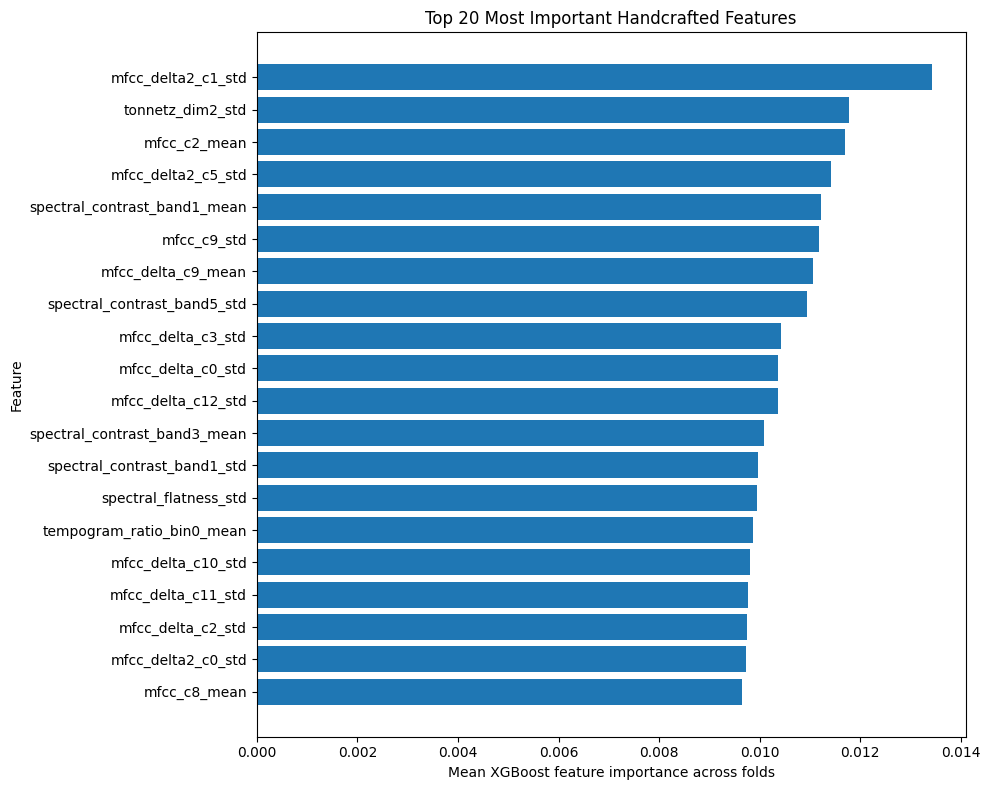

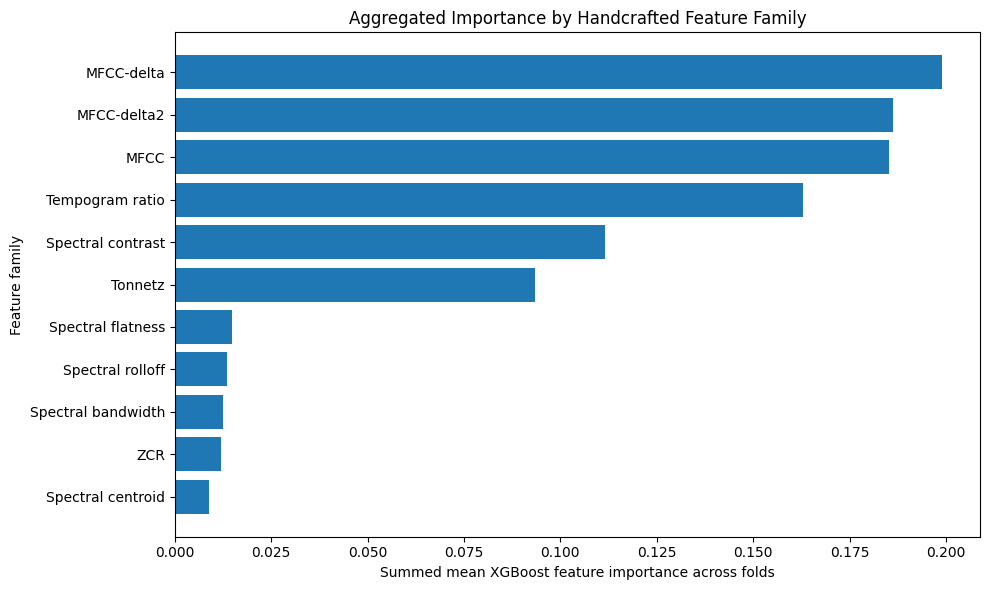


Saved:
- StressID/outputs/handcrafted/importance/hc_feature_importance_folds_groupkfold.csv
- StressID/outputs/handcrafted/importance/hc_feature_importance_individual_groupkfold.csv
- StressID/outputs/handcrafted/importance/hc_feature_importance_grouped_groupkfold.csv


In [14]:
# ============================================================
# 7. Feature Importance Analysis
# ============================================================
# This cell:
#   1) Reconstructs the exact handcrafted feature-name mapping (140 features)
#   2) Trains an XGBoost classifier on the handcrafted feature matrix
#   3) Computes individual feature importances
#   4) Aggregates importances by feature family
#   5) Exposes two plots:
#        - Top-N individual features
#        - Aggregated importance by feature group
#
# IMPORTANT:
# - This analysis is descriptive and uses the full handcrafted dataset (X_audio, y_audio).
# - It is intended for interpretability, not for final benchmark reporting.
# - It assumes X_audio was built from the handcrafted 140-dimensional features.

# ============================================================
# 7. Feature Importance Analysis (CV-aligned + Optuna-tuned)
# ============================================================

assert "best_xgb_params_hc" in locals(), "best_xgb_params_hc not found. Run the Optuna tuning cell first."
assert "X_audio" in locals(), "X_audio not found."
assert "y_audio" in locals(), "y_audio not found."
assert X_audio.shape[1] == 140, f"Expected 140 handcrafted features, got {X_audio.shape[1]}."

# ------------------------------------------------------------
# 1) Exact handcrafted feature-name mapping
# ------------------------------------------------------------
feature_names_hc = []

feature_names_hc += [f"mfcc_c{i}_mean" for i in range(13)]
feature_names_hc += [f"mfcc_c{i}_std" for i in range(13)]

feature_names_hc += [f"mfcc_delta_c{i}_mean" for i in range(13)]
feature_names_hc += [f"mfcc_delta_c{i}_std" for i in range(13)]

feature_names_hc += [f"mfcc_delta2_c{i}_mean" for i in range(13)]
feature_names_hc += [f"mfcc_delta2_c{i}_std" for i in range(13)]

feature_names_hc += ["spectral_centroid_mean", "spectral_centroid_std"]
feature_names_hc += ["spectral_bandwidth_mean", "spectral_bandwidth_std"]
feature_names_hc += ["spectral_flatness_mean", "spectral_flatness_std"]

feature_names_hc += [f"spectral_contrast_band{i}_mean" for i in range(7)]
feature_names_hc += [f"spectral_contrast_band{i}_std" for i in range(7)]

feature_names_hc += ["spectral_rolloff_mean", "spectral_rolloff_std"]

feature_names_hc += [f"tonnetz_dim{i}_mean" for i in range(6)]
feature_names_hc += [f"tonnetz_dim{i}_std" for i in range(6)]

feature_names_hc += ["zcr_mean", "zcr_std"]

feature_names_hc += [f"tempogram_ratio_bin{i}_mean" for i in range(13)]
feature_names_hc += [f"tempogram_ratio_bin{i}_std" for i in range(13)]

assert len(feature_names_hc) == 140

feature_groups_hc = (
    ["MFCC"] * 13 +
    ["MFCC"] * 13 +
    ["MFCC-delta"] * 13 +
    ["MFCC-delta"] * 13 +
    ["MFCC-delta2"] * 13 +
    ["MFCC-delta2"] * 13 +
    ["Spectral centroid"] * 2 +
    ["Spectral bandwidth"] * 2 +
    ["Spectral flatness"] * 2 +
    ["Spectral contrast"] * 7 +
    ["Spectral contrast"] * 7 +
    ["Spectral rolloff"] * 2 +
    ["Tonnetz"] * 6 +
    ["Tonnetz"] * 6 +
    ["ZCR"] * 2 +
    ["Tempogram ratio"] * 13 +
    ["Tempogram ratio"] * 13
)

assert len(feature_groups_hc) == 140

# ------------------------------------------------------------
# 2) CV selection
# ------------------------------------------------------------
USE_GROUPKFOLD_IMPORTANCE = True

X_audio_np = np.asarray(X_audio, dtype=np.float32)
y_audio_np = np.asarray(y_audio, dtype=np.int64)

if USE_GROUPKFOLD_IMPORTANCE:
    assert "groups_audio" in locals(), "groups_audio not found, but USE_GROUPKFOLD_IMPORTANCE=True."
    groups_audio_np = np.asarray(groups_audio)
    cv = GroupKFold(n_splits=n_folds)
    split_iter = cv.split(X_audio_np, y_audio_np, groups_audio_np)
    cv_suffix = "groupkfold"
else:
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    split_iter = cv.split(X_audio_np, y_audio_np)
    cv_suffix = "stratifiedkfold"

# ------------------------------------------------------------
# 3) Fold-wise importances
# ------------------------------------------------------------
fold_rows = []

for fold_idx, (train_idx, test_idx) in enumerate(split_iter, start=1):
    X_train = X_audio_np[train_idx]
    y_train = y_audio_np[train_idx]

    n_pos = int(np.sum(y_train == 1))
    n_neg = int(np.sum(y_train == 0))
    scale_pos_weight = (n_neg / n_pos) if n_pos > 0 else 1.0

    model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        **best_xgb_params_hc
    )

    model.fit(X_train, y_train)

    importances = model.feature_importances_

    df_fold = pd.DataFrame({
        "fold": fold_idx,
        "feature_idx": np.arange(140),
        "feature_name": feature_names_hc,
        "feature_group": feature_groups_hc,
        "importance": importances
    })

    fold_rows.append(df_fold)

df_importance_folds = pd.concat(fold_rows, ignore_index=True)

# ------------------------------------------------------------
# 4) Individual feature summary
# ------------------------------------------------------------
df_importance = (
    df_importance_folds
    .groupby(["feature_idx", "feature_name", "feature_group"], as_index=False)
    .agg(
        importance_mean=("importance", "mean"),
        importance_std=("importance", "std")
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

print("====================================================")
print(" TOP 20 INDIVIDUAL HANDCRAFTED FEATURES")
print("====================================================")
print(df_importance.head(20).to_string(index=False))

# ------------------------------------------------------------
# 5) Aggregated family importance
# ------------------------------------------------------------
df_group_importance = (
    df_importance
    .groupby("feature_group", as_index=False)["importance_mean"]
    .sum()
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

print("\n====================================================")
print(" AGGREGATED IMPORTANCE BY FEATURE FAMILY")
print("====================================================")
print(df_group_importance.to_string(index=False))

# ------------------------------------------------------------
# 6) Plots
# ------------------------------------------------------------
TOP_N = 20

df_top = df_importance.head(TOP_N).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(df_top["feature_name"], df_top["importance_mean"])
plt.xlabel("Mean XGBoost feature importance across folds")
plt.ylabel("Feature")
plt.title(f"Top {TOP_N} Most Important Handcrafted Features")
plt.tight_layout()
plt.show()

df_group_plot = df_group_importance.iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(df_group_plot["feature_group"], df_group_plot["importance_mean"])
plt.xlabel("Summed mean XGBoost feature importance across folds")
plt.ylabel("Feature family")
plt.title("Aggregated Importance by Handcrafted Feature Family")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7) Exports
# ------------------------------------------------------------
IMPORTANCE_DIR = os.path.join("StressID", "outputs", "handcrafted", "importance")
os.makedirs(IMPORTANCE_DIR, exist_ok=True)

importance_folds_path = os.path.join(IMPORTANCE_DIR, f"hc_feature_importance_folds_{cv_suffix}.csv")
importance_individual_path = os.path.join(IMPORTANCE_DIR, f"hc_feature_importance_individual_{cv_suffix}.csv")
importance_grouped_path = os.path.join(IMPORTANCE_DIR, f"hc_feature_importance_grouped_{cv_suffix}.csv")

df_importance_folds.to_csv(importance_folds_path, index=False)
df_importance.to_csv(importance_individual_path, index=False)
df_group_importance.to_csv(importance_grouped_path, index=False)

print("\nSaved:")
print(f"- {importance_folds_path}")
print(f"- {importance_individual_path}")
print(f"- {importance_grouped_path}")

# 3. Wav2Vec 2.0 pipeline

# 3.1. Wav2Vec 2.0 Embedding Extraction Methodology

&emsp;Deep acoustic representations are extracted using the Wav2Vec 2.0 framework following the implementation provided in the official <a href="https://github.com/robustml-eurecom/stressID/blob/main/Feature%20Extraction/audio/main.py" target="_blank">StressID GitHub repository</a>. A pretrained Wav2Vec model implemented in the Fairseq library is loaded from an external checkpoint and applied to each speech recording after Voice Activity Detection (VAD). The VAD stage removes non-speech segments to ensure that deep representations are computed exclusively over active speech regions. The resulting signal is then processed through the model’s convolutional feature extractor and feature aggregator modules. Temporal statistics are computed from the aggregated representation by calculating the mean and standard deviation across time, producing a fixed-length embedding suitable for downstream classification while remaining consistent with the original StressID feature extraction protocol.

In [15]:
# --- SECTION 8: Wav2Vec Feature Extraction ---

import torch

def DeepAudioFeatures(audio_path, W2Vmodel):
    speech, sr = librosa.load(audio_path, sr=None)

    speechVAD = Speech_silence_vad.silence_handler(
        speech, sr,
        fl=int(20 / 1000 * sr),
        fs=int(5 / 1000 * sr),
        max_thres_below=40,
        min_thres=-55,
        shortest_len_in_ms=50,
        flag_output=1
    )

    model = W2Vmodel[0]
    model.eval()

    with torch.no_grad():
        z = model.feature_extractor(torch.from_numpy(speechVAD).unsqueeze(0))
        z = model.feature_aggregator(z)

    w2v = z.cpu().numpy()
    w2v_mean = np.mean(w2v, axis=2)
    w2v_std = np.std(w2v, axis=2)

    return w2v_mean, w2v_std, w2v

def DeepAudioEmbedding(audio_path, W2Vmodel):
    """
    Extracts a fixed-length Wav2Vec 2.0 embedding for a given audio file.

    The function applies the StressID deep feature extraction pipeline:
    1. Load the audio signal.
    2. Apply Voice Activity Detection (VAD) to remove non-speech segments.
    3. Pass the resulting signal through the Wav2Vec 2.0 feature extractor
       and feature aggregator implemented in Fairseq.
    4. Compute temporal statistics (mean and standard deviation) across
       the time dimension of the aggregated representation.

    The mean and standard deviation vectors are concatenated to produce
    a fixed-length embedding suitable for classical machine learning
    models such as kNN, SVM, or XGBoost.

    Parameters
    ----------
    audio_path : str
        Path to the audio file.

    W2Vmodel : list
        List containing the loaded Fairseq Wav2Vec model. The first
        element is expected to be the model instance.

    Returns
    -------
    np.ndarray
        1D numpy array containing the concatenated mean and standard
        deviation statistics of the Wav2Vec representation
        (typically 1024 dimensions: 512 mean + 512 std).
    """
    w2v_mean, w2v_std, _ = DeepAudioFeatures(audio_path, W2Vmodel)

    embedding = np.concatenate(
        [w2v_mean.squeeze(0), w2v_std.squeeze(0)],
        axis=0
    )

    return embedding

In [18]:
# =========================
# Load Wav2Vec model (Fairseq)
# =========================

import fairseq

checkpoint_path = os.path.join(WAV2VEC_MODELS_DIR, "wav2vec_large.pt")
#checkpoint_path = os.path.join(WAV2VEC_MODELS_DIR, "wav2vec_vox_new.pt")

print("Loading Wav2Vec model...")

model, cfg, task = fairseq.checkpoint_utils.load_model_ensemble_and_task([checkpoint_path])
W2Vmodel = model

print("Wav2Vec model loaded successfully.")



Loading Wav2Vec model...


2026-04-23 15:07:22 | INFO | fairseq.models.wav2vec.wav2vec | Wav2VecModel(
  (feature_extractor): ConvFeatureExtractionModel(
    (conv_layers): ModuleList(
      (0): Sequential(
        (0): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (1): Dropout(p=0.0, inplace=False)
        (2): Fp32GroupNorm(1, 512, eps=1e-05, affine=True)
        (3): ReLU()
      )
      (1): Sequential(
        (0): Conv1d(512, 512, kernel_size=(8,), stride=(4,), bias=False)
        (1): Dropout(p=0.0, inplace=False)
        (2): Fp32GroupNorm(1, 512, eps=1e-05, affine=True)
        (3): ReLU()
      )
      (2-4): 3 x Sequential(
        (0): Conv1d(512, 512, kernel_size=(4,), stride=(2,), bias=False)
        (1): Dropout(p=0.0, inplace=False)
        (2): Fp32GroupNorm(1, 512, eps=1e-05, affine=True)
        (3): ReLU()
      )
      (5-6): 2 x Sequential(
        (0): Conv1d(512, 512, kernel_size=(1,), stride=(1,), bias=False)
        (1): Dropout(p=0.0, inplace=False)
        (2): F

Wav2Vec model loaded successfully.


## 3.1. Dataset-Level Wav2Vec 2.0 Embedding Construction and Caching

&emsp;This section constructs the dataset-level deep embedding matrix required for supervised learning while incorporating a caching mechanism to improve reproducibility and computational efficiency. For each StressID speech sample selected during corpus ingestion, the Wav2Vec 2.0 embedding extractor is applied to generate a fixed-length representation based on the temporal mean and standard deviation of the aggregated deep features. These embeddings are assembled into the matrix $X_{w2v}$, accompanied by the corresponding label vector $y_{w2v}$ and subject grouping vector used for subject-independent evaluation. If a previously computed embedding dataset is detected, the user is informed of the last extraction timestamp and may choose either to reuse the cached dataset or to recompute the embeddings from scratch, in which case the existing cache is overwritten.

In [19]:
# =========================
# 9. Dataset-Level Wav2Vec 2.0 Embedding Construction and Caching
# =========================

W2V_FEATURE_CACHE = os.path.join(CACHE_DIR, "stressid_w2v_embeddings.parquet")
W2V_META_FILE = os.path.join(CACHE_DIR, "stressid_w2v_embeddings_meta.txt")

use_cached_w2v = False

# -------------------------------------------------
# 1. Check whether cached W2V embeddings already exist
# -------------------------------------------------
if os.path.exists(W2V_FEATURE_CACHE):
    print("====================================================")
    print(" EXISTING W2V EMBEDDING CACHE DETECTED             ")
    print("====================================================")

    if os.path.exists(W2V_META_FILE):
        with open(W2V_META_FILE, "r") as f:
            print(f.read())

    user_input = input("Reuse cached W2V embeddings instead of recomputing from scratch? (y/n): ").strip().lower()

    if user_input == "y":
        print("Using existing cached W2V embedding dataset.")
        use_cached_w2v = True
    else:
        print("Cached W2V embeddings will be ignored. A new extraction will be performed and will overwrite the existing cache.")

# -------------------------------------------------
# 2. Load cached W2V embeddings
# -------------------------------------------------
if use_cached_w2v:
    df_w2v = pd.read_parquet(W2V_FEATURE_CACHE)

    feature_cols = [col for col in df_w2v.columns if col.startswith("f_")]

    X_w2v = df_w2v[feature_cols].values.astype(np.float32)
    y_w2v = df_w2v["label"].values.astype(np.int64)
    groups_w2v = df_w2v["subject"].values.astype(object)

    print("====================================================")
    print(" LOADED CACHED W2V EMBEDDING DATASET               ")
    print("====================================================")
    print(f"Samples: {X_w2v.shape[0]}")
    print(f"Embedding dim: {X_w2v.shape[1]}")
    print(f"Positive class ratio (y=1): {float(np.mean(y_w2v)):.3f}")
    print("====================================================")

# -------------------------------------------------
# 3. Compute W2V embeddings from scratch
# -------------------------------------------------
else:
    required_cols = {"filepath", "subject", "binary-stress"}
    assert "df_sid" in locals(), "df_sid not found. Run corpus ingestion first."
    assert required_cols.issubset(set(df_sid.columns)), f"df_sid must contain columns: {required_cols}"
    assert "W2Vmodel" in locals(), "W2Vmodel not found. Load the Fairseq Wav2Vec model first."

    X_w2v_list = []
    y_w2v_list = []
    groups_w2v_list = []
    failed_files = []

    for _, row in tqdm.tqdm(df_sid.iterrows(), total=len(df_sid), desc="Extracting W2V embeddings"):
        audio_path = row["filepath"]
        y = int(row["binary-stress"])
        subject = row["subject"]

        try:
            emb = DeepAudioEmbedding(audio_path, W2Vmodel)
            X_w2v_list.append(emb)
            y_w2v_list.append(y)
            groups_w2v_list.append(subject)
        except Exception as e:
            failed_files.append((audio_path, str(e)))

    n_ok = len(X_w2v_list)
    n_fail = len(failed_files)

    print("====================================================")
    print(" DATASET-LEVEL W2V EMBEDDING CONSTRUCTION SUMMARY  ")
    print("====================================================")
    print(f"Total rows in df_sid: {len(df_sid)}")
    print(f"Successful extractions: {n_ok}")
    print(f"Failed extractions: {n_fail}")

    if n_fail > 0:
        print("\nFirst 10 failures:")
        for p, err in failed_files[:10]:
            print(f" - {p}\n   {err}")

    assert n_ok > 0, "No W2V embeddings were extracted successfully. See failures above."

    X_w2v = np.vstack(X_w2v_list).astype(np.float32)
    y_w2v = np.array(y_w2v_list, dtype=np.int64)
    groups_w2v = np.array(groups_w2v_list, dtype=object)

    print("\n====================================================")
    print(" DATASET-LEVEL W2V EMBEDDING CONSTRUCTION COMPLETE ")
    print("====================================================")
    print(f"Extracted samples: {X_w2v.shape[0]}/{len(df_sid)}")
    print(f"Embedding dim: {X_w2v.shape[1]}")
    print(f"Positive class ratio (y=1): {float(np.mean(y_w2v)):.3f}")
    print(f"Failed files: {len(failed_files)}")

    # Save / overwrite cache
    feature_cols = [f"f_{i}" for i in range(X_w2v.shape[1])]
    df_w2v = pd.DataFrame(X_w2v, columns=feature_cols)
    df_w2v["label"] = y_w2v
    df_w2v["subject"] = groups_w2v

    df_w2v.to_parquet(W2V_FEATURE_CACHE, index=False)

    extraction_timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    meta_text = (
        f"Last extraction timestamp: {extraction_timestamp}\n"
        f"Samples: {len(df_w2v)}\n"
        f"Embedding dimension: {X_w2v.shape[1]}\n"
        f"Positive ratio: {float(np.mean(y_w2v)):.3f}\n"
        f"Cache file: {W2V_FEATURE_CACHE}\n"
    )

    with open(W2V_META_FILE, "w") as f:
        f.write(meta_text)

    print("\n====================================================")
    print(" W2V EMBEDDING DATASET SAVED / OVERWRITTEN         ")
    print("====================================================")
    print(meta_text)
    print("====================================================")

 EXISTING W2V EMBEDDING CACHE DETECTED             
Last extraction timestamp: 2026-04-17 15:44:39
Samples: 378
Embedding dimension: 1024
Positive ratio: 0.709
Cache file: /home/gaba/Documents/Facultad/Tesis/GitHub/thesis-stress-recognition/experiments/cache/stressid_w2v_embeddings.parquet



Reuse cached W2V embeddings instead of recomputing from scratch? (y/n):  y


Using existing cached W2V embedding dataset.
 LOADED CACHED W2V EMBEDDING DATASET               
Samples: 378
Embedding dim: 1024
Positive class ratio (y=1): 0.709


## 3.3. Baseline Evaluation on Wav2Vec 2.0 Embeddings

&emsp;This section evaluates the predictive capacity of deep audio representations extracted with the Wav2Vec 2.0 model. The embeddings generated in Section 8 are used as input features for the same baseline classifiers previously applied to the handcrafted descriptors.

&emsp;To ensure methodological consistency, the evaluation protocol remains unchanged. Two complementary validation strategies are employed. First, stratified 5-fold cross-validation is used to estimate classification performance at the sample level while preserving class balance across folds. Second, a subject-independent evaluation is conducted using GroupKFold, ensuring that recordings from the same participant do not appear simultaneously in training and validation partitions.

&emsp;This experimental setup enables a direct comparison between traditional handcrafted acoustic descriptors and self-supervised deep speech representations.

In [20]:
# ============================================================
# LOAD W2V EMBEDDING DATASET
# ============================================================

import pandas as pd
import numpy as np

df_w2v = pd.read_parquet(W2V_FEATURE_CACHE)

print("====================================================")
print(" W2V EMBEDDING DATASET LOADED")
print("====================================================")

print("Samples:", len(df_w2v))
print("Columns:", len(df_w2v.columns))
print()

# Feature matrix
feature_cols = [c for c in df_w2v.columns if c.startswith("f_")]

X_w2v = df_w2v[feature_cols].values.astype(np.float32)

# Labels
y_w2v = df_w2v["label"].values.astype(np.int64)

# Subject IDs (for GroupKFold)
groups_w2v = df_w2v["subject"].values

print("Embedding dimension:", X_w2v.shape[1])
print("Positive ratio:", np.mean(y_w2v))

 W2V EMBEDDING DATASET LOADED
Samples: 378
Columns: 1026

Embedding dimension: 1024
Positive ratio: 0.708994708994709


In [21]:
# ============================================================
# BASELINE CLASSIFIERS
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

K_neighbors = 5
# Available SVM kernels in scikit-learn: linear, rbf, poly, sigmoid, etc.
SVM_kernel = "rbf"

models = {
    f"kNN (k={K_neighbors})": KNeighborsClassifier(n_neighbors=K_neighbors),
    f"SVM ({SVM_kernel})": SVC(kernel=SVM_kernel, C=1.0, gamma="scale")
}

print("Models initialized:")
for name in models:
    print("-", name)

Models initialized:
- kNN (k=5)
- SVM (rbf)


In [22]:
# ============================================================
# STRATIFIED 5-FOLD CROSS VALIDATION
# ============================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score

skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

w2v_strat_results = {}

print("====================================================")
print(" STRATIFIED 5-FOLD CV RESULTS (W2V EMBEDDINGS)")
print("====================================================")

for name, model in models.items():

    f1_scores = []
    acc_scores = []
    bacc_scores = []

    for train_idx, test_idx in skf.split(X_w2v, y_w2v):

        X_train, X_test = X_w2v[train_idx], X_w2v[test_idx]
        y_train, y_test = y_w2v[train_idx], y_w2v[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        f1_scores.append(f1_score(y_test, y_pred, average="weighted"))
        acc_scores.append(accuracy_score(y_test, y_pred))
        bacc_scores.append(balanced_accuracy_score(y_test, y_pred))

    w2v_strat_results[name] = {
        "f1_mean": np.mean(f1_scores),
        "f1_std": np.std(f1_scores, ddof=1),
        "acc_mean": np.mean(acc_scores),
        "acc_std": np.std(acc_scores, ddof=1),
        "bacc_mean": np.mean(bacc_scores),
        "bacc_std": np.std(bacc_scores, ddof=1),
    }

    print(name)
    print(f"Mean weighted F1:     {w2v_strat_results[name]['f1_mean']:.4f}")
    print(f"Std  weighted F1:     {w2v_strat_results[name]['f1_std']:.4f}")
    print(f"Mean accuracy:        {w2v_strat_results[name]['acc_mean']:.4f}")
    print(f"Std  accuracy:        {w2v_strat_results[name]['acc_std']:.4f}")
    print(f"Mean balanced acc.:   {w2v_strat_results[name]['bacc_mean']:.4f}")
    print(f"Std  balanced acc.:   {w2v_strat_results[name]['bacc_std']:.4f}")
    print()

 STRATIFIED 5-FOLD CV RESULTS (W2V EMBEDDINGS)
kNN (k=5)
Mean weighted F1:     0.6929
Std  weighted F1:     0.0446
Mean accuracy:        0.7089
Std  accuracy:        0.0443
Mean balanced acc.:   0.6099
Std  balanced acc.:   0.0542

SVM (rbf)
Mean weighted F1:     0.6173
Std  weighted F1:     0.0290
Mean accuracy:        0.7222
Std  accuracy:        0.0134
Mean balanced acc.:   0.5227
Std  balanced acc.:   0.0227



In [23]:
# ============================================================
# SUBJECT-INDEPENDENT CV
# ============================================================

from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score

gkf = GroupKFold(n_splits=n_folds)

w2v_group_results = {}

print("====================================================")
print(" SUBJECT-INDEPENDENT CV RESULTS (W2V EMBEDDINGS)")
print("====================================================")

for name, model in models.items():

    f1_scores = []
    acc_scores = []
    bacc_scores = []

    for train_idx, test_idx in gkf.split(X_w2v, y_w2v, groups_w2v):

        X_train, X_test = X_w2v[train_idx], X_w2v[test_idx]
        y_train, y_test = y_w2v[train_idx], y_w2v[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        f1_scores.append(f1_score(y_test, y_pred, average="weighted"))
        acc_scores.append(accuracy_score(y_test, y_pred))
        bacc_scores.append(balanced_accuracy_score(y_test, y_pred))

    w2v_group_results[name] = {
        "f1_mean": np.mean(f1_scores),
        "f1_std": np.std(f1_scores, ddof=1),
        "acc_mean": np.mean(acc_scores),
        "acc_std": np.std(acc_scores, ddof=1),
        "bacc_mean": np.mean(bacc_scores),
        "bacc_std": np.std(bacc_scores, ddof=1),
    }

    print(name)
    print(f"Mean weighted F1:     {w2v_group_results[name]['f1_mean']:.4f}")
    print(f"Std  weighted F1:     {w2v_group_results[name]['f1_std']:.4f}")
    print(f"Mean accuracy:        {w2v_group_results[name]['acc_mean']:.4f}")
    print(f"Std  accuracy:        {w2v_group_results[name]['acc_std']:.4f}")
    print(f"Mean balanced acc.:   {w2v_group_results[name]['bacc_mean']:.4f}")
    print(f"Std  balanced acc.:   {w2v_group_results[name]['bacc_std']:.4f}")
    print()

 SUBJECT-INDEPENDENT CV RESULTS (W2V EMBEDDINGS)
kNN (k=5)
Mean weighted F1:     0.6338
Std  weighted F1:     0.0176
Mean accuracy:        0.6582
Std  accuracy:        0.0299
Mean balanced acc.:   0.5366
Std  balanced acc.:   0.0159

SVM (rbf)
Mean weighted F1:     0.5874
Std  weighted F1:     0.0417
Mean accuracy:        0.7081
Std  accuracy:        0.0319
Mean balanced acc.:   0.5000
Std  balanced acc.:   0.0000



# 4. Comparative Results Summary

## 4.1. Stratified Cross-Validation Results

This subsection presents the consolidated results obtained under the stratified cross-validation protocol. Its purpose is to provide a direct comparison between the handcrafted-feature models and the Wav2Vec 2.0-based models using the same evaluation metrics. In this way, the relative behavior of the different feature representations and classifiers can be assessed in a single view, instead of being inferred from separate sections.

The comparison is reported in terms of weighted F1-score, accuracy, and balanced accuracy. Weighted F1-score is especially relevant because it summarizes classification performance while accounting for class imbalance. Accuracy provides an overall measure of correct predictions, whereas balanced accuracy complements it by giving equal importance to both classes. Taken together, these metrics provide a more complete view of model behavior than any single metric alone.

This consolidated presentation makes it possible to identify the strongest configuration under the stratified setting and to determine whether the use of deep embeddings yields an improvement over the handcrafted baseline. It also helps quantify the gain obtained by the optimized XGBoost model with respect to the conventional baseline classifiers.

In [27]:
# ============================================================
# 4.1. Stratified Cross-Validation Results
# ============================================================

import pandas as pd

def fmt(mean, std):
    return f"{mean:.4f} ± {std:.4f}"

stratified_rows = []

# ------------------------------------------------------------
# Authors' reported results (StressID paper, 2-class)
# ------------------------------------------------------------
stratified_rows.append({
    "Feature Type": "Handcrafted",
    "Model": "kNN (authors)",
    "Weighted F1-score": "0.6700 ± 0.0600",
    "Accuracy": "0.6000 ± 0.0500",
    "Balanced Accuracy": "—"
})

stratified_rows.append({
    "Feature Type": "Handcrafted",
    "Model": "SVM (authors)",
    "Weighted F1-score": "0.6100 ± 0.0600",
    "Accuracy": "0.5400 ± 0.0300",
    "Balanced Accuracy": "—"
})

stratified_rows.append({
    "Feature Type": "Wav2Vec 2.0",
    "Model": "W2V 2.0 classifier (authors)",
    "Weighted F1-score": "0.7000 ± 0.0200",
    "Accuracy": "0.6600 ± 0.0300",
    "Balanced Accuracy": "—"
})

# ------------------------------------------------------------
# Local handcrafted baselines
# ------------------------------------------------------------
stratified_rows.append({
    "Feature Type": "Handcrafted",
    "Model": "kNN (local)",
    "Weighted F1-score": fmt(hc_baseline_strat_results["knn_f1_mean"], hc_baseline_strat_results["knn_f1_std"]),
    "Accuracy": fmt(hc_baseline_strat_results["knn_acc_mean"], hc_baseline_strat_results["knn_acc_std"]),
    "Balanced Accuracy": fmt(hc_baseline_strat_results["knn_bacc_mean"], hc_baseline_strat_results["knn_bacc_std"])
})

stratified_rows.append({
    "Feature Type": "Handcrafted",
    "Model": "SVM (local)",
    "Weighted F1-score": fmt(hc_baseline_strat_results["svm_f1_mean"], hc_baseline_strat_results["svm_f1_std"]),
    "Accuracy": fmt(hc_baseline_strat_results["svm_acc_mean"], hc_baseline_strat_results["svm_acc_std"]),
    "Balanced Accuracy": fmt(hc_baseline_strat_results["svm_bacc_mean"], hc_baseline_strat_results["svm_bacc_std"])
})

# ------------------------------------------------------------
# Local tuned XGBoost
# ------------------------------------------------------------
stratified_rows.append({
    "Feature Type": "Handcrafted",
    "Model": "XGBoost (Optuna-tuned, local)",
    "Weighted F1-score": fmt(xgb_hc_strat_results["f1_mean"], xgb_hc_strat_results["f1_std"]),
    "Accuracy": fmt(xgb_hc_strat_results["acc_mean"], xgb_hc_strat_results["acc_std"]),
    "Balanced Accuracy": fmt(xgb_hc_strat_results["bacc_mean"], xgb_hc_strat_results["bacc_std"])
})

# ------------------------------------------------------------
# Local Wav2Vec 2.0 models
# ------------------------------------------------------------
for name, res in w2v_strat_results.items():
    stratified_rows.append({
        "Feature Type": "Wav2Vec 2.0",
        "Model": f"{name} (local)",
        "Weighted F1-score": fmt(res["f1_mean"], res["f1_std"]),
        "Accuracy": fmt(res["acc_mean"], res["acc_std"]),
        "Balanced Accuracy": fmt(res["bacc_mean"], res["bacc_std"])
    })

df_results_stratified = pd.DataFrame(stratified_rows)

print("====================================================")
print(" 4.1. STRATIFIED CROSS-VALIDATION RESULTS")
print("====================================================")
print(df_results_stratified.to_string(index=False))

 4.1. STRATIFIED CROSS-VALIDATION RESULTS
Feature Type                         Model Weighted F1-score        Accuracy Balanced Accuracy
 Handcrafted                 kNN (authors)   0.6700 ± 0.0600 0.6000 ± 0.0500                 —
 Handcrafted                 SVM (authors)   0.6100 ± 0.0600 0.5400 ± 0.0300                 —
 Wav2Vec 2.0  W2V 2.0 classifier (authors)   0.7000 ± 0.0200 0.6600 ± 0.0300                 —
 Handcrafted                   kNN (local)   0.6802 ± 0.0503 0.7090 ± 0.0492   0.5831 ± 0.0531
 Handcrafted                   SVM (local)   0.6201 ± 0.0210 0.6058 ± 0.0234   0.5800 ± 0.0296
 Handcrafted XGBoost (Optuna-tuned, local)   0.6788 ± 0.0382 0.6851 ± 0.0376   0.6010 ± 0.0452
 Wav2Vec 2.0             kNN (k=5) (local)   0.6929 ± 0.0446 0.7089 ± 0.0443   0.6099 ± 0.0542
 Wav2Vec 2.0             SVM (rbf) (local)   0.6173 ± 0.0290 0.7222 ± 0.0134   0.5227 ± 0.0227


## 4.2. Subject-Independent Results

This subsection summarizes the results obtained under the subject-independent evaluation scheme. Unlike stratified cross-validation, this protocol is more demanding because it measures the capacity of the models to generalize to unseen speakers. For this reason, it provides a more realistic estimate of the practical robustness of the proposed approaches in stress recognition.

As in the previous subsection, the results are reported through weighted F1-score, accuracy, and balanced accuracy. Presenting these metrics jointly is particularly important in the subject-independent setting, where performance degradation may appear differently depending on the metric considered. In particular, balanced accuracy is useful for verifying whether the classifier maintains a reasonable sensitivity-specificity trade-off when evaluated on unseen subjects.

This section enables a direct comparison of the generalization gap between the stratified and subject-independent protocols. Such a comparison is valuable because it reveals whether the observed performance is associated mainly with speaker-dependent patterns or with more stable stress-related cues that transfer across speakers.

In [30]:
# ============================================================
# 4.2. Subject-Independent Results
# ============================================================

import pandas as pd

def fmt(mean, std):
    return f"{mean:.4f} ± {std:.4f}"

group_rows = []

# Handcrafted tuned XGBoost
if "xgb_hc_group_results" in locals():
    group_rows.append({
        "Feature Type": "Handcrafted",
        "Model": "XGBoost (Optuna-tuned)",
        "Weighted F1-score": fmt(xgb_hc_group_results["f1_mean"], xgb_hc_group_results["f1_std"]),
        "Accuracy": fmt(xgb_hc_group_results["acc_mean"], xgb_hc_group_results["acc_std"]),
        "Balanced Accuracy": fmt(xgb_hc_group_results["bacc_mean"], xgb_hc_group_results["bacc_std"])
    })
else:
    print("Warning: xgb_hc_group_results is not defined. Handcrafted group results will be omitted.")

# Wav2Vec models
for name, res in w2v_group_results.items():
    group_rows.append({
        "Feature Type": "Wav2Vec 2.0",
        "Model": name,
        "Weighted F1-score": fmt(res["f1_mean"], res["f1_std"]),
        "Accuracy": fmt(res["acc_mean"], res["acc_std"]),
        "Balanced Accuracy": fmt(res["bacc_mean"], res["bacc_std"])
    })

df_results_group = pd.DataFrame(group_rows)

print("====================================================")
print(" 4.2. SUBJECT-INDEPENDENT RESULTS")
print("====================================================")
print(df_results_group.to_string(index=False))

 4.2. SUBJECT-INDEPENDENT RESULTS
Feature Type                  Model Weighted F1-score        Accuracy Balanced Accuracy
 Handcrafted XGBoost (Optuna-tuned)   0.6550 ± 0.0527 0.6683 ± 0.0532   0.5661 ± 0.0727
 Wav2Vec 2.0              kNN (k=5)   0.6338 ± 0.0176 0.6582 ± 0.0299   0.5366 ± 0.0159
 Wav2Vec 2.0              SVM (rbf)   0.5874 ± 0.0417 0.7081 ± 0.0319   0.5000 ± 0.0000
